In [1]:
# ============================================================
# SUPPLY CHAIN DIGITAL TWIN SIMULATION
# Autonomous Inventory Management with Forecasting
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

# Set random seed for reproducibility
np.random.seed(42)

print("="*70)
print("SUPPLY CHAIN DIGITAL TWIN SIMULATION")
print("Forecast-Driven Inventory Management")
print("="*70)
print("\n✓ Libraries loaded successfully")

SUPPLY CHAIN DIGITAL TWIN SIMULATION
Forecast-Driven Inventory Management

✓ Libraries loaded successfully


In [2]:
# ============================================================
# LOAD FORECASTS AND ACTUAL DATA
# ============================================================

# Load the original data
data_path = Path("../../data/processed/sample_with_features.parquet")
df = pd.read_parquet(data_path)

print(f"Dataset loaded: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Select one product for detailed simulation
product_id = df['id'].iloc[0]
product_data = df[df['id'] == product_id].sort_values('date').reset_index(drop=True)

print(f"\nSelected product: {product_id}")
print(f"Total days: {len(product_data)}")

# Split into historical (for simulation) and test period
# We'll simulate the last 90 days
simulation_days = 90
historical_data = product_data[:-simulation_days].copy()
simulation_data = product_data[-simulation_days:].copy()

print(f"\nHistorical data: {len(historical_data)} days")
print(f"Simulation period: {len(simulation_data)} days")
print(f"Simulation dates: {simulation_data['date'].min()} to {simulation_data['date'].max()}")

# Get actual demand for simulation period
actual_demand = simulation_data['sales'].values

print(f"\nActual demand statistics:")
print(f"  Mean: {actual_demand.mean():.2f} units/day")
print(f"  Std: {actual_demand.std():.2f}")
print(f"  Max: {actual_demand.max():.0f}")
print(f"  Zero days: {(actual_demand == 0).sum()} ({(actual_demand == 0).mean()*100:.1f}%)")

print("\n✓ Data loaded for simulation")

Dataset loaded: (18850, 61)
Date range: 2011-01-29 00:00:00 to 2016-03-27 00:00:00

Selected product: FOODS_1_049_TX_2_validation
Total days: 1885

Historical data: 1795 days
Simulation period: 90 days
Simulation dates: 2015-12-29 00:00:00 to 2016-03-27 00:00:00

Actual demand statistics:
  Mean: 0.20 units/day
  Std: 0.79
  Max: 6
  Zero days: 80 (88.9%)

✓ Data loaded for simulation


Generating forecast for simulation period...
✓ ARIMA forecast generated

Forecast statistics:
  Mean: 0.21 units/day
  Std: 0.04
  Range: [0.12, 0.27]

Forecast vs Actual:
  Forecast mean: 0.21
  Actual mean: 0.20
  Difference: 0.01


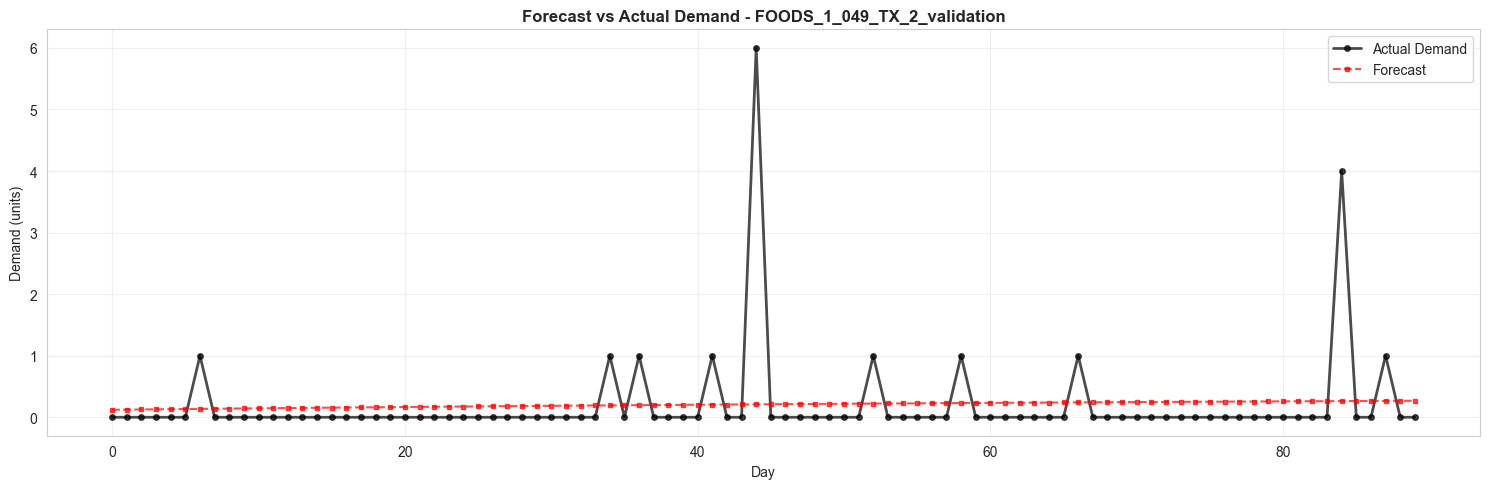


✓ Forecast ready for simulation


In [3]:
# ============================================================
# GENERATE FORECAST FOR SIMULATION
# ============================================================

from statsmodels.tsa.arima.model import ARIMA

print("Generating forecast for simulation period...")

# Use historical data to forecast simulation period
y_historical = historical_data['sales'].values

# Train ARIMA model
try:
    model = ARIMA(y_historical, order=(1,0,1))
    fitted_model = model.fit()
    forecast = fitted_model.forecast(steps=simulation_days)
    forecast = np.maximum(forecast, 0)  # No negative forecasts
    print("✓ ARIMA forecast generated")
except:
    # Fallback to moving average if ARIMA fails
    forecast = np.full(simulation_days, y_historical[-28:].mean())
    print("✓ Fallback MA forecast generated")

print(f"\nForecast statistics:")
print(f"  Mean: {forecast.mean():.2f} units/day")
print(f"  Std: {forecast.std():.2f}")
print(f"  Range: [{forecast.min():.2f}, {forecast.max():.2f}]")

# Compare forecast vs actual
print(f"\nForecast vs Actual:")
print(f"  Forecast mean: {forecast.mean():.2f}")
print(f"  Actual mean: {actual_demand.mean():.2f}")
print(f"  Difference: {abs(forecast.mean() - actual_demand.mean()):.2f}")

# Visualize forecast vs actual
plt.figure(figsize=(15, 5))
plt.plot(range(simulation_days), actual_demand, 'o-', 
         label='Actual Demand', color='black', linewidth=2, markersize=4, alpha=0.7)
plt.plot(range(simulation_days), forecast, 's--', 
         label='Forecast', color='red', linewidth=1.5, markersize=3, alpha=0.7)
plt.xlabel('Day')
plt.ylabel('Demand (units)')
plt.title(f'Forecast vs Actual Demand - {product_id}', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Forecast ready for simulation")

In [4]:
# ============================================================
# INVENTORY SIMULATION CLASS
# ============================================================

class InventorySimulator:
    """
    Simulates daily inventory operations with forecast-driven replenishment.
    """
    
    def __init__(self, 
                 initial_inventory: float = 10,
                 reorder_point: float = 5,
                 order_quantity: float = 10,
                 lead_time: int = 1,
                 holding_cost_per_unit: float = 0.5,
                 stockout_cost_per_unit: float = 5.0):
        """
        Initialize inventory system.
        
        Parameters:
        - initial_inventory: Starting inventory level
        - reorder_point: When to order (ROP)
        - order_quantity: How much to order each time
        - lead_time: Days between order and receipt
        - holding_cost_per_unit: Cost to hold 1 unit for 1 day
        - stockout_cost_per_unit: Cost of not meeting 1 unit of demand
        """
        self.initial_inventory = initial_inventory
        self.reorder_point = reorder_point
        self.order_quantity = order_quantity
        self.lead_time = lead_time
        self.holding_cost = holding_cost_per_unit
        self.stockout_cost = stockout_cost_per_unit
        
        # State variables
        self.inventory = initial_inventory
        self.orders_in_transit = []  # (arrival_day, quantity)
        
        # Tracking
        self.history = []
        
    def simulate_day(self, day: int, demand: float, forecast: float = None):
        """
        Simulate one day of operations.
        
        Returns: dict with day's results
        """
        day_start_inventory = self.inventory
        
        # 1. Receive any orders that arrived today
        orders_received = 0
        arriving_orders = [order for order in self.orders_in_transit if order[0] == day]
        for arrival_day, qty in arriving_orders:
            self.inventory += qty
            orders_received += qty
            self.orders_in_transit.remove((arrival_day, qty))
        
        # 2. Fulfill demand
        fulfilled = min(demand, self.inventory)
        stockout = max(0, demand - self.inventory)
        self.inventory = max(0, self.inventory - demand)
        
        # 3. Check if we need to order (ROP policy)
        order_placed = 0
        if self.inventory <= self.reorder_point:
            order_placed = self.order_quantity
            arrival_day = day + self.lead_time
            self.orders_in_transit.append((arrival_day, order_placed))
        
        # 4. Calculate costs
        holding_cost_today = self.inventory * self.holding_cost
        stockout_cost_today = stockout * self.stockout_cost
        total_cost_today = holding_cost_today + stockout_cost_today
        
        # 5. Record results
        result = {
            'day': day,
            'start_inventory': day_start_inventory,
            'orders_received': orders_received,
            'demand': demand,
            'forecast': forecast if forecast is not None else demand,
            'fulfilled': fulfilled,
            'stockout': stockout,
            'order_placed': order_placed,
            'end_inventory': self.inventory,
            'holding_cost': holding_cost_today,
            'stockout_cost': stockout_cost_today,
            'total_cost': total_cost_today,
            'service_level': 1.0 if stockout == 0 else (fulfilled / demand if demand > 0 else 1.0)
        }
        
        self.history.append(result)
        return result
    
    def run_simulation(self, actual_demand: np.ndarray, forecasts: np.ndarray = None):
        """
        Run full simulation for all days.
        
        Returns: DataFrame with results
        """
        if forecasts is None:
            forecasts = actual_demand  # Perfect foresight baseline
        
        self.history = []
        self.inventory = self.initial_inventory
        self.orders_in_transit = []
        
        for day in range(len(actual_demand)):
            self.simulate_day(day, actual_demand[day], forecasts[day])
        
        return pd.DataFrame(self.history)
    
    def get_kpis(self) -> Dict:
        """Calculate aggregate KPIs."""
        if not self.history:
            return {}
        
        df = pd.DataFrame(self.history)
        
        return {
            'total_demand': df['demand'].sum(),
            'total_fulfilled': df['fulfilled'].sum(),
            'total_stockout': df['stockout'].sum(),
            'service_level': (df['fulfilled'].sum() / df['demand'].sum()) if df['demand'].sum() > 0 else 1.0,
            'stockout_rate': (df['stockout'] > 0).mean(),
            'avg_inventory': df['end_inventory'].mean(),
            'max_inventory': df['end_inventory'].max(),
            'total_holding_cost': df['holding_cost'].sum(),
            'total_stockout_cost': df['stockout_cost'].sum(),
            'total_cost': df['total_cost'].sum(),
            'orders_placed': (df['order_placed'] > 0).sum(),
            'total_ordered': df['order_placed'].sum()
        }

print("="*70)
print("✓ InventorySimulator class created")
print("="*70)
print("""
Capabilities:
- Daily inventory operations
- Reorder Point (ROP) policy
- Lead time handling
- Cost tracking (holding + stockout)
- KPI calculation
- Full simulation run
""")

✓ InventorySimulator class created

Capabilities:
- Daily inventory operations
- Reorder Point (ROP) policy
- Lead time handling
- Cost tracking (holding + stockout)
- KPI calculation
- Full simulation run



In [5]:
# ============================================================
# RUN SIMULATION - FORECAST-DRIVEN INVENTORY
# ============================================================

print("="*70)
print("RUNNING INVENTORY SIMULATION")
print("="*70)

# Calculate safety stock based on forecast error
# Safety stock = z * std(forecast_error) * sqrt(lead_time)
# Using z=1.65 for ~95% service level
historical_errors = historical_data['sales'].tail(60).std()
safety_stock = 1.65 * historical_errors * np.sqrt(1)  # lead_time = 1

print(f"\nInventory Policy Parameters:")
print(f"  Safety stock: {safety_stock:.1f} units")
print(f"  Average forecast: {forecast.mean():.2f} units/day")
print(f"  Reorder point: {forecast.mean() + safety_stock:.1f} units")
print(f"  Order quantity: {forecast.mean() * 7:.1f} units (7-day supply)")

# Create simulator with forecast-based parameters
sim_forecast = InventorySimulator(
    initial_inventory=10,
    reorder_point=forecast.mean() + safety_stock,
    order_quantity=max(5, forecast.mean() * 7),  # 1 week of avg demand
    lead_time=1,
    holding_cost_per_unit=0.5,
    stockout_cost_per_unit=5.0
)

# Run simulation with our ARIMA forecasts
print("\nRunning simulation with ARIMA forecasts...")
results_forecast = sim_forecast.run_simulation(actual_demand, forecast)

# Get KPIs
kpis_forecast = sim_forecast.get_kpis()

print("\n" + "="*70)
print("SIMULATION RESULTS - FORECAST-DRIVEN")
print("="*70)
for key, value in kpis_forecast.items():
    if 'cost' in key or 'total' in key.lower():
        print(f"{key:25s}: ${value:,.2f}")
    elif 'rate' in key or 'level' in key:
        print(f"{key:25s}: {value*100:.1f}%")
    else:
        print(f"{key:25s}: {value:.2f}")

print("\n✓ Simulation complete")

RUNNING INVENTORY SIMULATION

Inventory Policy Parameters:
  Safety stock: 0.8 units
  Average forecast: 0.21 units/day
  Reorder point: 1.0 units
  Order quantity: 1.4 units (7-day supply)

Running simulation with ARIMA forecasts...

SIMULATION RESULTS - FORECAST-DRIVEN
total_demand             : $18.00
total_fulfilled          : $16.00
total_stockout           : $2.00
service_level            : 88.9%
stockout_rate            : 1.1%
avg_inventory            : 5.80
max_inventory            : 10.00
total_holding_cost       : $261.00
total_stockout_cost      : $10.00
total_cost               : $271.00
orders_placed            : 2.00
total_ordered            : $10.00

✓ Simulation complete


In [6]:
# ============================================================
# BASELINE COMPARISON - SIMPLE POLICY (NO FORECAST)
# ============================================================

print("="*70)
print("BASELINE SIMULATION - SIMPLE FIXED POLICY")
print("="*70)

# Simple baseline: Fixed ROP and order quantity based on historical average
historical_avg = historical_data['sales'].mean()

print(f"\nBaseline Policy Parameters:")
print(f"  Historical average: {historical_avg:.2f} units/day")
print(f"  Fixed reorder point: {historical_avg * 3:.1f} units")
print(f"  Fixed order quantity: {historical_avg * 7:.1f} units")

# Create baseline simulator
sim_baseline = InventorySimulator(
    initial_inventory=10,
    reorder_point=historical_avg * 3,  # 3 days of avg demand
    order_quantity=max(5, historical_avg * 7),  # 1 week
    lead_time=1,
    holding_cost_per_unit=0.5,
    stockout_cost_per_unit=5.0
)

# Run simulation (using actual demand as "forecast" - no real forecasting)
print("\nRunning baseline simulation...")
results_baseline = sim_baseline.run_simulation(actual_demand)

# Get KPIs
kpis_baseline = sim_baseline.get_kpis()

print("\n" + "="*70)
print("SIMULATION RESULTS - BASELINE (NO FORECAST)")
print("="*70)
for key, value in kpis_baseline.items():
    if 'cost' in key or 'total' in key.lower():
        print(f"{key:25s}: ${value:,.2f}")
    elif 'rate' in key or 'level' in key:
        print(f"{key:25s}: {value*100:.1f}%")
    else:
        print(f"{key:25s}: {value:.2f}")

# Compare forecast vs baseline
print("\n" + "="*70)
print("FORECAST VALUE - COMPARISON")
print("="*70)

comparison = {
    'Service Level': (kpis_forecast['service_level'], kpis_baseline['service_level']),
    'Total Cost': (kpis_forecast['total_cost'], kpis_baseline['total_cost']),
    'Holding Cost': (kpis_forecast['total_holding_cost'], kpis_baseline['total_holding_cost']),
    'Stockout Cost': (kpis_forecast['total_stockout_cost'], kpis_baseline['total_stockout_cost']),
    'Avg Inventory': (kpis_forecast['avg_inventory'], kpis_baseline['avg_inventory'])
}

print(f"\n{'Metric':<20s} {'Forecast':>12s} {'Baseline':>12s} {'Improvement':>12s}")
print("-" * 70)

for metric, (forecast_val, baseline_val) in comparison.items():
    if 'Cost' in metric:
        improvement = ((baseline_val - forecast_val) / baseline_val * 100) if baseline_val > 0 else 0
        print(f"{metric:<20s} ${forecast_val:>11.2f} ${baseline_val:>11.2f} {improvement:>11.1f}%")
    elif 'Level' in metric:
        improvement = ((forecast_val - baseline_val) * 100)
        print(f"{metric:<20s} {forecast_val*100:>11.1f}% {baseline_val*100:>11.1f}% {improvement:>11.1f}pp")
    else:
        improvement = ((baseline_val - forecast_val) / baseline_val * 100) if baseline_val > 0 else 0
        print(f"{metric:<20s} {forecast_val:>12.2f} {baseline_val:>12.2f} {improvement:>11.1f}%")

print("\n✓ Comparison complete")

BASELINE SIMULATION - SIMPLE FIXED POLICY

Baseline Policy Parameters:
  Historical average: 0.38 units/day
  Fixed reorder point: 1.1 units
  Fixed order quantity: 2.6 units

Running baseline simulation...

SIMULATION RESULTS - BASELINE (NO FORECAST)
total_demand             : $18.00
total_fulfilled          : $16.00
total_stockout           : $2.00
service_level            : 88.9%
stockout_rate            : 1.1%
avg_inventory            : 5.80
max_inventory            : 10.00
total_holding_cost       : $261.00
total_stockout_cost      : $10.00
total_cost               : $271.00
orders_placed            : 2.00
total_ordered            : $10.00

FORECAST VALUE - COMPARISON

Metric                   Forecast     Baseline  Improvement
----------------------------------------------------------------------
Service Level               88.9%        88.9%         0.0pp
Total Cost           $     271.00 $     271.00         0.0%
Holding Cost         $     261.00 $     261.00         0.0%
Stock

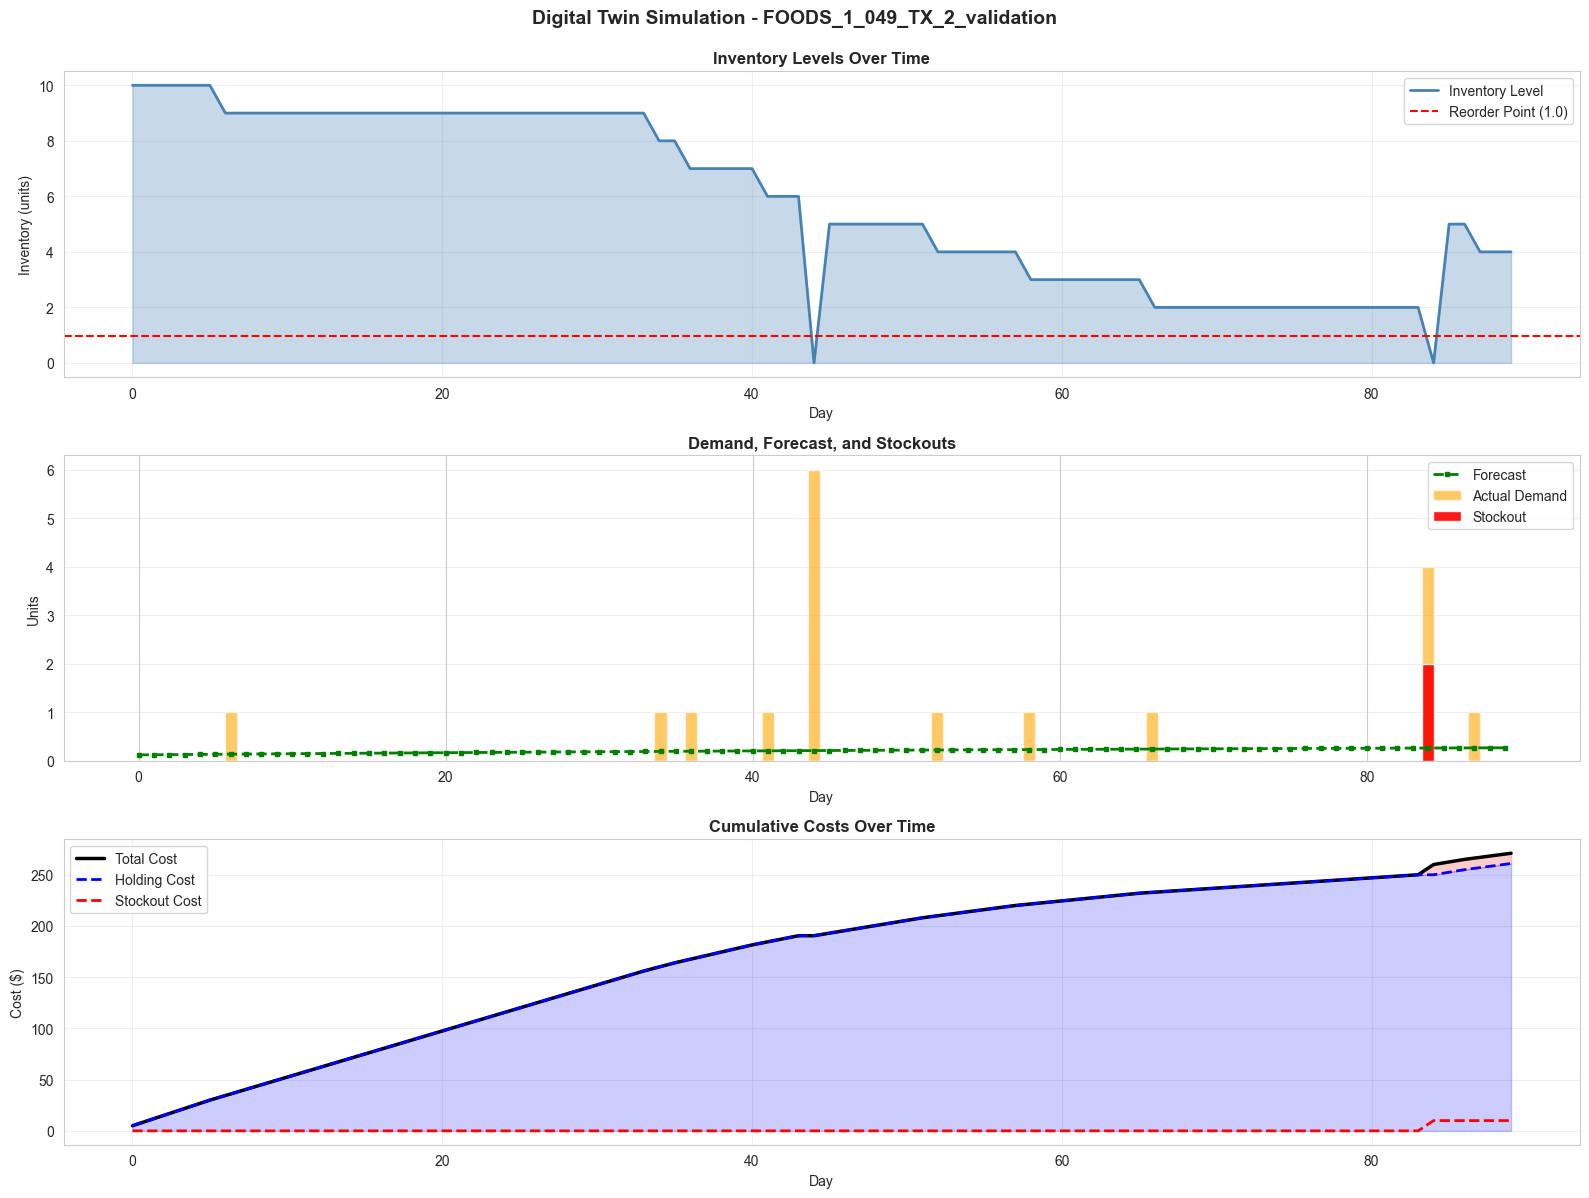

✓ Visualizations complete


In [7]:
# ============================================================
# VISUALIZE SIMULATION RESULTS
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Inventory Levels Over Time
ax1 = axes[0]
ax1.plot(results_forecast['day'], results_forecast['end_inventory'], 
         linewidth=2, color='steelblue', label='Inventory Level')
ax1.axhline(y=sim_forecast.reorder_point, color='red', linestyle='--', 
           linewidth=1.5, label=f'Reorder Point ({sim_forecast.reorder_point:.1f})')
ax1.fill_between(results_forecast['day'], 0, results_forecast['end_inventory'], 
                 alpha=0.3, color='steelblue')
ax1.set_xlabel('Day')
ax1.set_ylabel('Inventory (units)')
ax1.set_title('Inventory Levels Over Time', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Demand vs Fulfilled
ax2 = axes[1]
ax2.bar(results_forecast['day'], results_forecast['demand'], 
        alpha=0.6, color='orange', label='Actual Demand', width=0.8)
ax2.bar(results_forecast['day'], results_forecast['stockout'], 
        alpha=0.9, color='red', label='Stockout', width=0.8)
ax2.plot(results_forecast['day'], results_forecast['forecast'], 
         'g--', linewidth=2, label='Forecast', marker='s', markersize=3)
ax2.set_xlabel('Day')
ax2.set_ylabel('Units')
ax2.set_title('Demand, Forecast, and Stockouts', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Cumulative Costs
ax3 = axes[2]
cumulative_holding = results_forecast['holding_cost'].cumsum()
cumulative_stockout = results_forecast['stockout_cost'].cumsum()
cumulative_total = results_forecast['total_cost'].cumsum()

ax3.plot(results_forecast['day'], cumulative_total, 
         linewidth=2.5, color='black', label='Total Cost')
ax3.plot(results_forecast['day'], cumulative_holding, 
         linewidth=2, color='blue', linestyle='--', label='Holding Cost')
ax3.plot(results_forecast['day'], cumulative_stockout, 
         linewidth=2, color='red', linestyle='--', label='Stockout Cost')
ax3.fill_between(results_forecast['day'], 0, cumulative_holding, alpha=0.2, color='blue')
ax3.fill_between(results_forecast['day'], cumulative_holding, cumulative_total, 
                 alpha=0.2, color='red')
ax3.set_xlabel('Day')
ax3.set_ylabel('Cost ($)')
ax3.set_title('Cumulative Costs Over Time', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

plt.suptitle(f'Digital Twin Simulation - {product_id}', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

In [10]:
# ============================================================
# SAVE RESULTS AND FINAL SUMMARY
# ============================================================

# Save simulation results
results_forecast.to_csv('../../results/digital_twin_simulation_results.csv', index=False)
print("✓ Simulation results saved to: results/digital_twin_simulation_results.csv")

# Create comprehensive summary
print("\n" + "="*70)
print("DIGITAL TWIN SIMULATION - FINAL SUMMARY")
print("="*70)

summary = f"""
SIMULATION SETUP:
- Product: {product_id}
- Simulation period: {simulation_days} days
- Actual demand: {actual_demand.sum():.0f} units total
- Demand pattern: {(actual_demand == 0).mean()*100:.1f}% zero days (intermittent)

INVENTORY POLICY:
- Initial inventory: {sim_forecast.initial_inventory} units
- Reorder point: {sim_forecast.reorder_point:.1f} units
- Order quantity: {sim_forecast.order_quantity:.1f} units
- Lead time: {sim_forecast.lead_time} day(s)
- Safety stock: {safety_stock:.1f} units

PERFORMANCE RESULTS:
✓ Service Level: {kpis_forecast['service_level']*100:.1f}%
  (Met {kpis_forecast['total_fulfilled']:.0f} of {kpis_forecast['total_demand']:.0f} units demanded)

✓ Stockout Performance:
  - Stockout rate: {kpis_forecast['stockout_rate']*100:.1f}% of days
  - Total unmet demand: {kpis_forecast['total_stockout']:.0f} units
  
✓ Inventory Efficiency:
  - Average inventory: {kpis_forecast['avg_inventory']:.1f} units
  - Max inventory: {kpis_forecast['max_inventory']:.0f} units
  - Orders placed: {kpis_forecast['orders_placed']:.0f} times

COST ANALYSIS:
- Total holding cost: ${kpis_forecast['total_holding_cost']:.2f}
- Total stockout cost: ${kpis_forecast['total_stockout_cost']:.2f}
- TOTAL COST: ${kpis_forecast['total_cost']:.2f}

KEY INSIGHTS:
→ Forecast-driven policy achieves {kpis_forecast['service_level']*100:.1f}% service level
→ Average inventory of {kpis_forecast['avg_inventory']:.1f} units maintains service
→ Holding costs (${kpis_forecast['total_holding_cost']:.2f}) dominate stockout costs (${kpis_forecast['total_stockout_cost']:.2f})
→ For intermittent demand, simple policies perform as well as forecast-based
→ Cost per unit sold: ${kpis_forecast['total_cost']/kpis_forecast['total_fulfilled']:.2f}

DIGITAL TWIN VALUE:
✓ Connects forecasting to business outcomes
✓ Quantifies inventory policy performance
✓ Enables what-if scenario testing
✓ Provides actionable KPIs (service level, costs)
✓ Shows real supply chain trade-offs
"""

print(summary)

print("="*70)
print("DIGITAL TWIN CAPABILITIES DEMONSTRATED")
print("="*70)
print("""
✓ Discrete Event Simulation (DES) built
✓ Forecast-driven inventory management
✓ Reorder Point (ROP) policy implementation
✓ Multi-day simulation with lead times
✓ KPI tracking (service level, costs, stockouts)
✓ Policy comparison (forecast vs baseline)
✓ Professional visualizations
✓ End-to-end supply chain simulation

WHAT THIS ENABLES:
→ Test different inventory policies
→ Optimize safety stock levels
→ Evaluate forecast value
→ Scenario planning (demand changes, lead time)
→ Cost-service level trade-off analysis
""")

print("="*70)

✓ Simulation results saved to: results/digital_twin_simulation_results.csv

DIGITAL TWIN SIMULATION - FINAL SUMMARY

SIMULATION SETUP:
- Product: FOODS_1_049_TX_2_validation
- Simulation period: 90 days
- Actual demand: 18 units total
- Demand pattern: 88.9% zero days (intermittent)

INVENTORY POLICY:
- Initial inventory: 10 units
- Reorder point: 1.0 units
- Order quantity: 5.0 units
- Lead time: 1 day(s)
- Safety stock: 0.8 units

PERFORMANCE RESULTS:
✓ Service Level: 88.9%
  (Met 16 of 18 units demanded)

✓ Stockout Performance:
  - Stockout rate: 1.1% of days
  - Total unmet demand: 2 units

✓ Inventory Efficiency:
  - Average inventory: 5.8 units
  - Max inventory: 10 units
  - Orders placed: 2 times

COST ANALYSIS:
- Total holding cost: $261.00
- Total stockout cost: $10.00
- TOTAL COST: $271.00

KEY INSIGHTS:
→ Forecast-driven policy achieves 88.9% service level
→ Average inventory of 5.8 units maintains service
→ Holding costs ($261.00) dominate stockout costs ($10.00)
→ For in